# 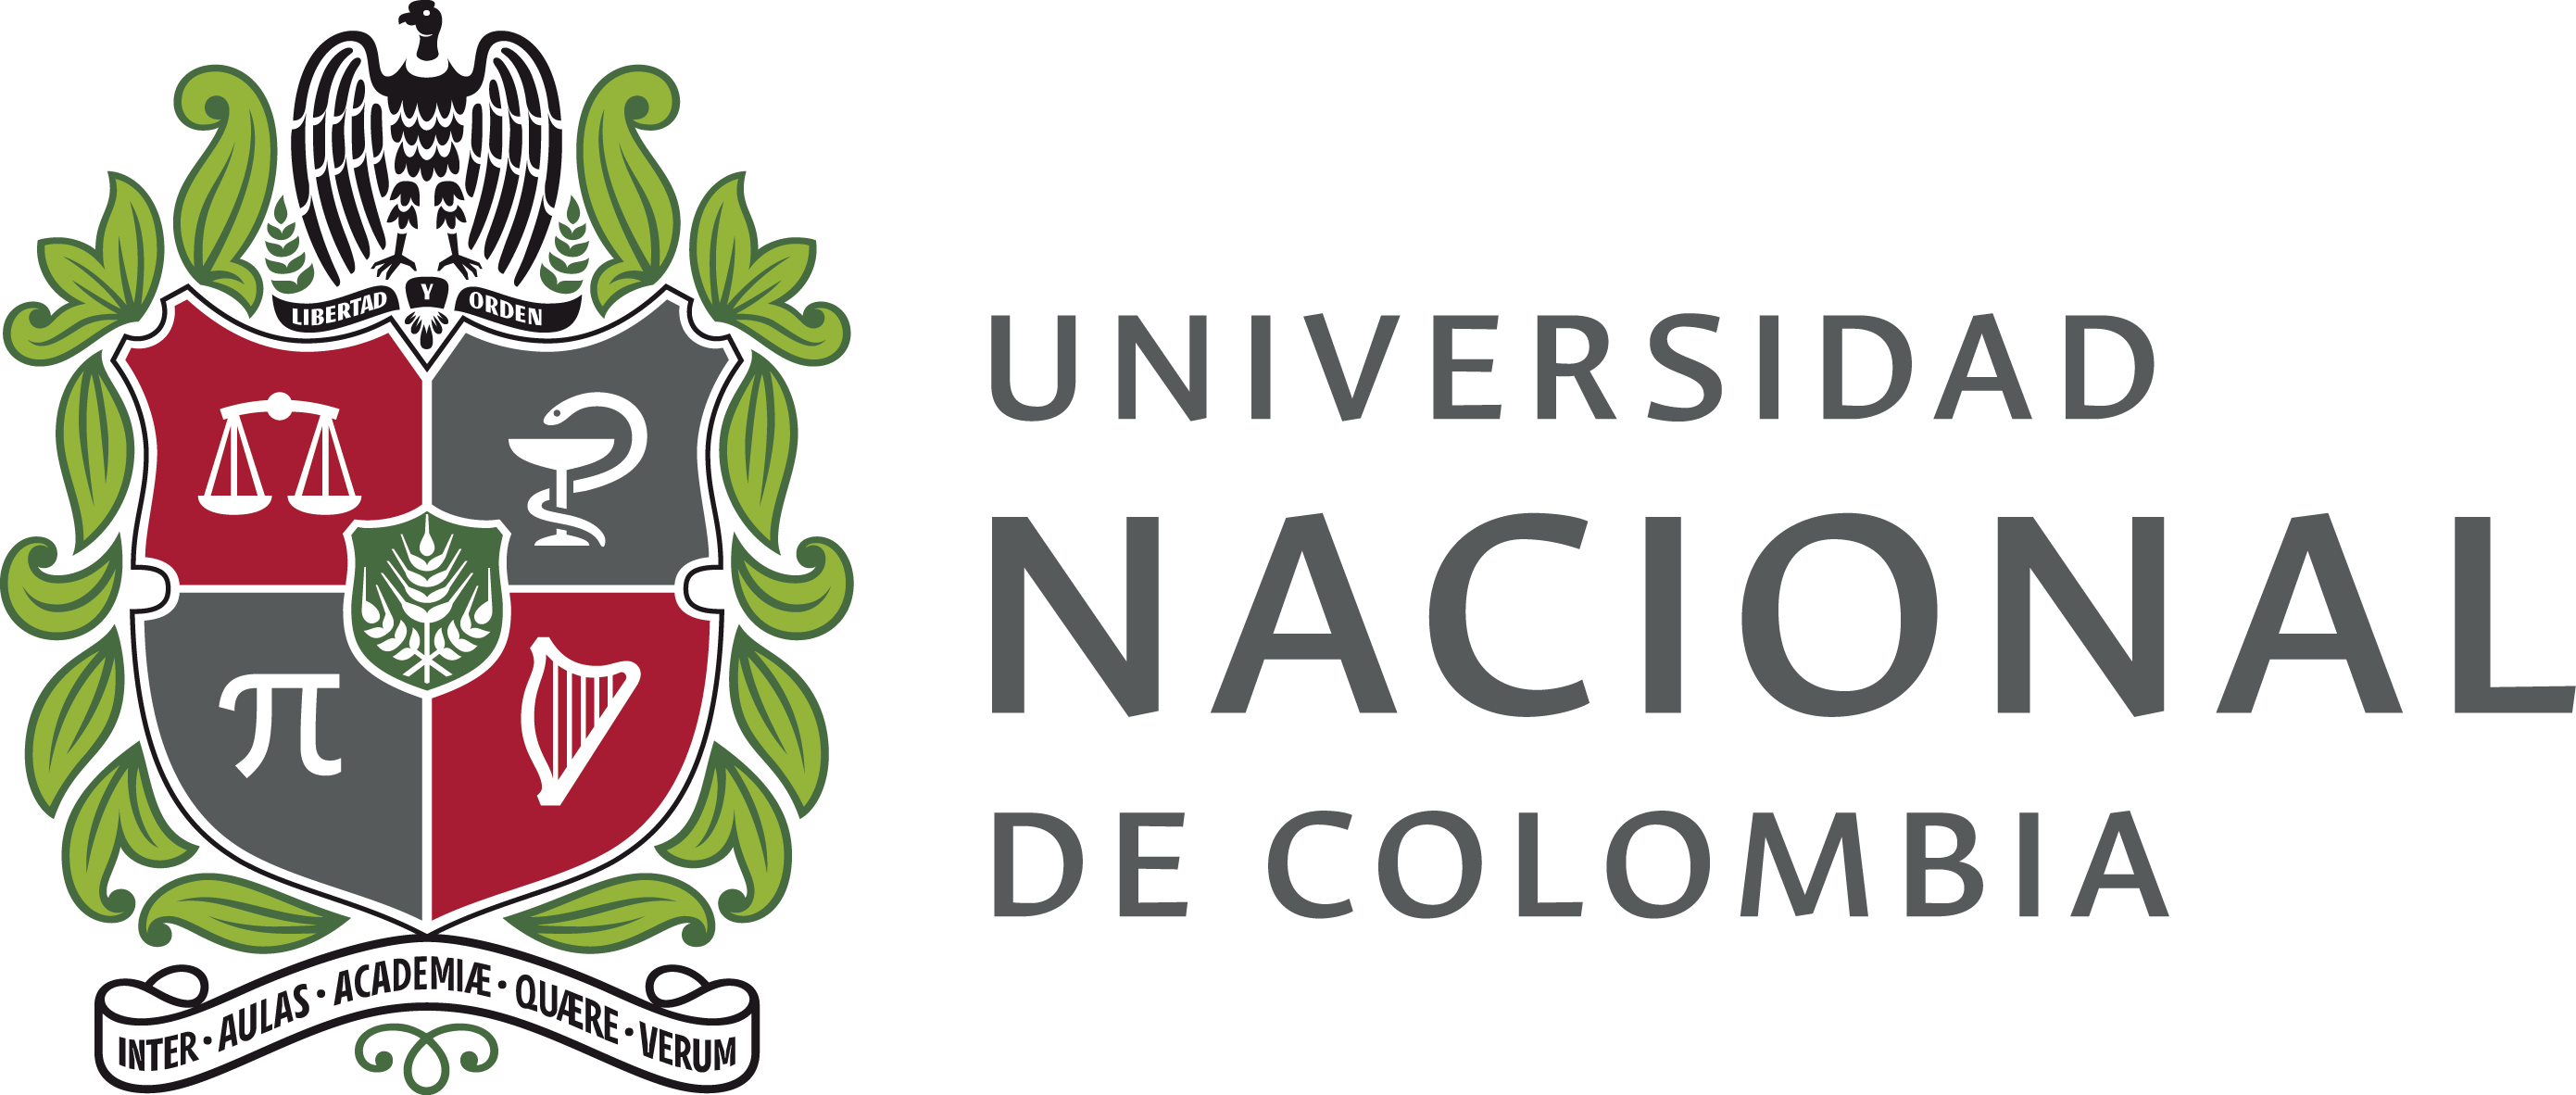

# Taller 3 — Minería de Datos (2016325)
**Análisis predictivo y estimación de costos sobre utilización de servicios de salud**

Metodología **CRISP-DM** sobre una base real de ~9 millones de utilizaciones de servicios de salud.
Todo el código está optimizado para ese volumen: operaciones **vectorizadas** (nunca funciones Python por grupo), tipos de datos livianos (`category`, `float32`) y gráficos sobre **muestras** cuando el gráfico no necesita todos los puntos.

> **Enfermedad seleccionada:** Diabetes mellitus — códigos CID **E10–E14** (CIE-10, OMS).
> Referencias de códigos: OMS ICD-10 Browser y tablas TUSS/ANS (Brasil).

## 1. Comprensión del problema

Cada registro de la base es una **utilización/procedimiento**. La unidad final de análisis es el **beneficiario** (`CHAVE_FUNCIONAL`), por lo que agregamos las transacciones.

**Pregunta:** ¿podemos predecir si un beneficiario pertenece al grupo con la enfermedad a partir de su perfil de utilización? Adicionalmente, ¿cuál es el **costo esperado** de una utilización asociada a la enfermedad?

**Granularidades**:
- Beneficiario → `CHAVE_FUNCIONAL`
- Utilización → `CHAVE_FUNCIONAL` + `DT_UTILIZACAO`
- Procedimiento → utilización + `CD_PROCEDIMENTO`

**Decisión anti-leakage:** `CID` se usa **solo** para construir el target y se excluye de las predictoras. Si el diagnóstico entrara como predictor, el modelo "predeciría" la enfermedad leyendo la etiqueta.

## 2. Preparación de los datos

### 2.1. Conexión a Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2.2. Librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, roc_curve)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

### 2.3. Carga eficiente del archivo

Las columnas categóricas como `category` nos ahorran costo computacional. Por ello codificamos las categorías con un mismo nombre

In [ ]:
ruta_del_archivo = '/content/drive/MyDrive/db_2026.csv'

# Columnas de texto repetitivo -> category (gran ahorro de memoria)
dtypes = {
    'SEXO_BENEFICIARIO': 'category',
    'TIPO_BENEFICIARIO': 'category',
    'UF_CNES_PREST_HOSPITALAR': 'category',
    'DESC_ESPECIALIDADE': 'category',
    'TIPO_UNIDADE_PREST_HOSPITALAR': 'category',
    'CETIPO': 'category',
    'PORTE_ANESTESICO': 'category',
    'INTERNADO': 'category',
    'UTI': 'category',
    'VALOR_UTILIZACAO': 'float32',
}

datos = pd.read_csv(ruta_del_archivo, dtype=dtypes, low_memory=False)
print("Dimensiones:", datos.shape)
print(f"Memoria: {datos.memory_usage(deep=True).sum()/1e9:.2f} GB")

Dimensiones: (9345278, 16)
Memoria: 3.36 GB


In [ ]:
datos.shape

(9345278, 20)

In [ ]:
datos.sample(8, random_state=RANDOM_STATE)

,CID,UTI,INTERNADO,PORTE_ANESTESICO,DT_UTILIZACAO,DESC_ESPECIALIDADE,TIPO_UNIDADE_PREST_HOSPITALAR,UF_CNES_PREST_HOSPITALAR,DT_NASCIMENTO_BENEFICIARIO,TIPO_BENEFICIARIO,SEXO_BENEFICIARIO,CETIPO,CD_PROCEDIMENTO,DESCRICAO_PROCEDIMENTO,VALOR_UTILIZACAO,CHAVE_FUNCIONAL
5363044,NaN,0,0,NaN,2026-03-04,-,CONSULTORIO ISOLADO,MG,1976-11-12,TITULAR,F,Exame,40808262,Biópsia percutânea de fragmento mamário por ag...,178.809998,ea12675e-11cc-4e71-982a-a7cb0df1d518
8386292,NaN,0,0,0,2026-01-15,-,CLINICA/CENTRO DE ESPECIALIDADE,RJ,1979-03-06,DEPENDENTE,F,Exame,40712303,Globulina de ligação de hormônios sexuais (SHBG),51.680000,93597c15-ed26-45c0-93e8-7a14860b2494
4514131,NaN,0,0,NaN,2026-01-12,CONSULTA EM ORTOPEDIA E TRAUMA,CLINICA/CENTRO DE ESPECIALIDADE,SP,1952-07-02,TITULAR,M,Outros,90101040,Outros registros não mapeados sem DePara,2.360000,968ab3fe-1396-4c76-9d2f-fb55e2ba08c0
6919810,NaN,0,0,0,2026-01-26,MEDICO CARDIOLOGISTA,CONSULTORIO ISOLADO,SP,1963-01-09,TITULAR,F,Exame,40901122,Abdome total (inclui pelve),13.190000,cd5d4f57-9a55-46fd-9a86-ae5d0384ca7c
5720713,NaN,0,0,NaN,2026-02-07,MEDICO CLINICO,CONSULTORIO ISOLADO,SP,1981-05-25,TITULAR,F,Exame,40316491,T4 livre - pesquisa e/ou dosagem,21.049999,58f270e8-2397-4da2-aac6-6ba1a4cc53eb
3812265,,0,0,0,2026-01-09,-,CLINICA/CENTRO DE ESPECIALIDADE,PR,2009-03-29,DEPENDENTE,F,Consulta,10101012,Em consultório (no horário normal ou preestabe...,91.599998,15443107-da2a-499c-bfe8-980cb7976407
969656,NaN,0,0,0,2026-02-28,-,UNIDADE DE APOIO DIAGNOSE E TERAPIA (SADT ISOL...,SP,1991-10-26,TITULAR,F,Exame,40311210,"Rotina de urina (caracteres físicos, elementos...",4.600000,791ae9cf-dce3-4651-8887-6849619cdb79
6883327,,0,0,NaN,2026-01-09,NaN,UNIDADE DE APOIO DIAGNOSE E TERAPIA (SADT ISOL...,RJ,1979-01-27,TITULAR,F,Exame,40316408,Progesterona - pesquisa e/ou dosagem,24.889999,11d1e6f2-fd0b-4101-abd1-7f507d84f8ab


### 2.4. Valores faltantes y duplicados

In [ ]:
faltantes = pd.DataFrame({
    'n_nulos': datos.isna().sum(),
    'pct_nulos': (datos.isna().mean() * 100).round(2)
}).sort_values('pct_nulos', ascending=False)
faltantes

,n_nulos,pct_nulos
CID,7824292,83.72
PORTE_ANESTESICO,4202557,44.97
DESC_ESPECIALIDADE,252814,2.71
DT_NASCIMENTO_BENEFICIARIO,1940,0.02
INTERNADO,0,0.00
DT_UTILIZACAO,0,0.00
TIPO_UNIDADE_PREST_HOSPITALAR,0,0.00
UTI,0,0.00
UF_CNES_PREST_HOSPITALAR,0,0.00
TIPO_BENEFICIARIO,0,0.00


In [ ]:
print("Filas duplicadas exactas:", datos.duplicated().sum())
# Decisión: los duplicados exactos se conservan salvo evidencia de error de carga,
# porque dos procedimientos idénticos el mismo día pueden ser legítimos.

Filas duplicadas exactas: 743862


### 2.5. Variable objetivo (sobre CID)

**Enfermedad: Diabetes mellitus** — crónica, de alta prevalencia y con
seguimiento recurrente, por lo que es identificable en la base y relevante en costos.

**Códigos CIE-10 (OMS): E10–E14**:
E10 tipo 1, E11 tipo 2, E12 por desnutrición, E13 otras, E14 no especificada.
Fuente: OMS ICD-10 Browser.

**Regla** beneficiario con ≥1 transacción con CID que inicie por E10–E14 → 1; si no → 0.

In [ ]:
NOMBRE_ENFERMEDAD = 'Diabetes mellitus'
CODIGOS_CID = ('E10', 'E11', 'E12', 'E13', 'E14')
# --------------------------------------------------------------------------------
cid = datos['CID'].astype('string').str.upper().str.strip()
datos['_es_enfermedad'] = cid.str.startswith(CODIGOS_CID, na=False)

benef_positivos = set(datos.loc[datos['_es_enfermedad'], 'CHAVE_FUNCIONAL'].unique())

print(f"Transacciones con CID de {NOMBRE_ENFERMEDAD}: {datos['_es_enfermedad'].sum():,}")
print(f"Beneficiarios positivos: {len(benef_positivos):,}")

Transacciones con CID de Diabetes mellitus: 4,631
Beneficiarios positivos: 57


### 2.6. Limpieza e inconsistencias

1. **Fechas:** se parsean con `errors='coerce'`; las inválidas quedan `NaT` y se cuantifican.
2. **Edad:** derivada de las fechas; valores fuera de [0, 110] → `NaN` (imputados luego por mediana dentro del pipeline).
3. **Costos negativos:** inválidos → `NaN`.
4. **Sexo contradictorio:** se detecta y cuantifica aquí; en la agregación se toma el primer valor no nulo por beneficiario.
5. **CID:** cumplida su función (target), no entra como predictora.

In [ ]:
datos['DT_NASCIMENTO_BENEFICIARIO'] = pd.to_datetime(datos['DT_NASCIMENTO_BENEFICIARIO'], errors='coerce')
datos['DT_UTILIZACAO']              = pd.to_datetime(datos['DT_UTILIZACAO'], errors='coerce')

datos['EDAD'] = ((datos['DT_UTILIZACAO'] - datos['DT_NASCIMENTO_BENEFICIARIO']).dt.days / 365.25).astype('float32')
datos.loc[(datos['EDAD'] < 0) | (datos['EDAD'] > 110), 'EDAD'] = np.nan
datos.loc[datos['VALOR_UTILIZACAO'] < 0, 'VALOR_UTILIZACAO'] = np.nan

print("Fechas de utilización inválidas:", datos['DT_UTILIZACAO'].isna().sum())
print("Edades inválidas/faltantes     :", datos['EDAD'].isna().sum())

Fechas de utilización inválidas: 0
Edades inválidas/faltantes     : 37947


In [ ]:
# Inconsistencias entre registros del mismo beneficiario (una sola pasada groupby-nunique, nativo)
incons = datos.groupby('CHAVE_FUNCIONAL', observed=True).agg(
    n_sexos  = ('SEXO_BENEFICIARIO', 'nunique'),
    n_fnac   = ('DT_NASCIMENTO_BENEFICIARIO', 'nunique'),
)
print(f"Beneficiarios con sexo contradictorio      : {(incons['n_sexos'] > 1).sum():,}")
print(f"Beneficiarios con >1 fecha de nacimiento   : {(incons['n_fnac'] > 1).sum():,}")
del incons  # liberar memoria

Beneficiarios con sexo contradictorio      : 525
Beneficiarios con >1 fecha de nacimiento   : 0


### 2.7. Valores extremos en `VALOR_UTILIZACAO`
gráficos sobre una muestra de 200k filas

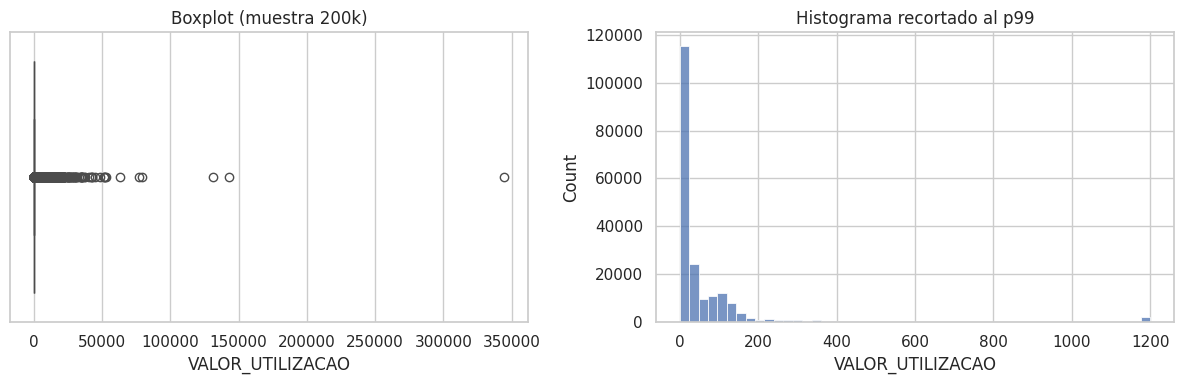

Límite IQR superior: 177.94 | Outliers: 687,182


In [ ]:
muestra = datos['VALOR_UTILIZACAO'].dropna().sample(min(200_000, datos['VALOR_UTILIZACAO'].notna().sum()),
                                                     random_state=RANDOM_STATE)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=muestra, ax=ax[0]); ax[0].set_title('Boxplot (muestra 200k)')
sns.histplot(muestra.clip(upper=muestra.quantile(0.99)), bins=50, ax=ax[1])
ax[1].set_title('Histograma recortado al p99')
plt.tight_layout(); plt.show()

q1, q3 = datos['VALOR_UTILIZACAO'].quantile([0.25, 0.75])
lim_sup = q3 + 1.5 * (q3 - q1)
print(f"Límite IQR superior: {lim_sup:,.2f} | Outliers: {(datos['VALOR_UTILIZACAO'] > lim_sup).sum():,}")
# Decisión: NO se eliminan los outliers de costo — en salud los costos extremos son
# reales (internaciones/UCI) y justamente lo que interesa modelar.

###Interpretación

- **CID** tiene **83.72%** de nulos. Como el target se construye sobre CID, ese
  subregistro masivo es la limitación más seria: muchos beneficiarios realmente
  diabéticos quedan etiquetados como 0 (falsos negativos en la etiqueta misma).
  El modelo hereda ese error desde el origen, no solo desde la predicción.
- **525** beneficiarios presentan sexo contradictorio. Es marginal;
  se resolvió tomando el primer valor no nulo por beneficiario.

## 3. Análisis descriptivo

In [ ]:
n_benef = datos['CHAVE_FUNCIONAL'].nunique()
n_util  = datos.groupby(['CHAVE_FUNCIONAL', 'DT_UTILIZACAO'], observed=True).ngroups
n_proc  = len(datos)

print(f"Beneficiarios  : {n_benef:,}")
print(f"Utilizaciones  : {n_util:,}   (combinación beneficiario+fecha, evita conteo duplicado)")
print(f"Procedimientos : {n_proc:,}")
print(f"% beneficiarios con {NOMBRE_ENFERMEDAD}: {len(benef_positivos)/n_benef*100:.2f}%")

Beneficiarios  : 653,631
Utilizaciones  : 2,250,307   (combinación beneficiario+fecha, evita conteo duplicado)
Procedimientos : 9,345,278
% beneficiarios con Diabetes mellitus: 0.01%


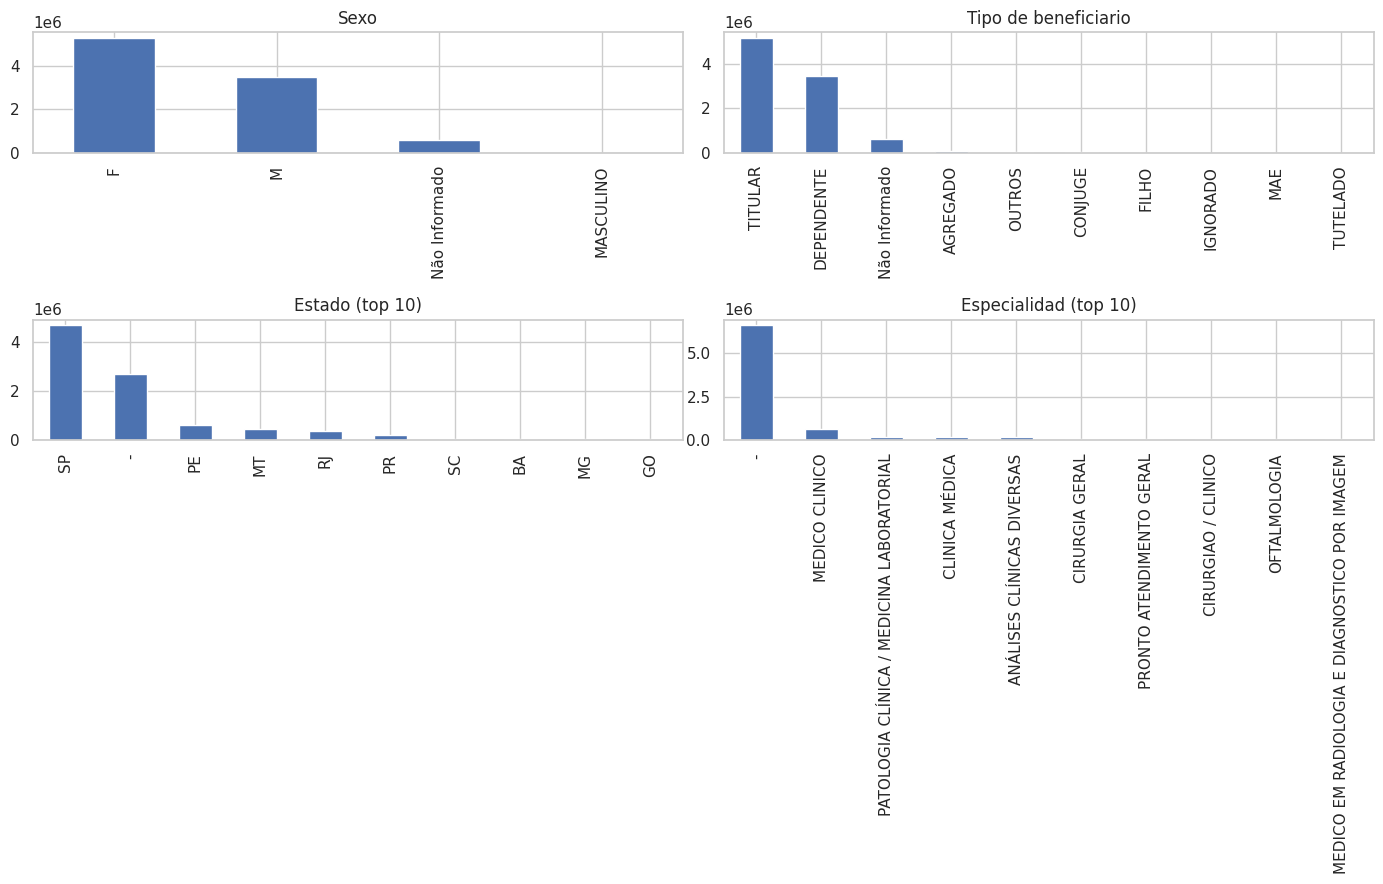

In [ ]:
# Distribuciones categóricas: value_counts es O(n) y barato
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col, titulo in zip(
        axes.ravel(),
        ['SEXO_BENEFICIARIO', 'TIPO_BENEFICIARIO', 'UF_CNES_PREST_HOSPITALAR', 'DESC_ESPECIALIDADE'],
        ['Sexo', 'Tipo de beneficiario', 'Estado (top 10)', 'Especialidad (top 10)']):
    datos[col].value_counts().head(10).plot(kind='bar', ax=ax)
    ax.set_title(titulo); ax.set_xlabel('')
plt.tight_layout(); plt.show()

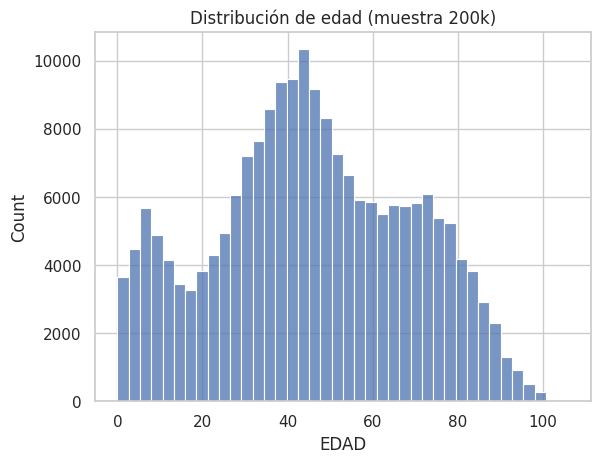

count    9307331.0
mean          45.6
std           23.1
min            0.0
25%           29.7
50%           44.8
75%           63.8
max          107.5
Name: EDAD, dtype: float64


In [ ]:
# Distribución de EDAD (histograma sobre muestra; estadísticos sobre todo)
edad_muestra = datos['EDAD'].dropna().sample(min(200_000, datos['EDAD'].notna().sum()),
                                             random_state=RANDOM_STATE)
sns.histplot(edad_muestra, bins=40)
plt.title('Distribución de edad (muestra 200k)'); plt.show()
print(datos['EDAD'].describe().round(1))

###Interpretación

- **Prevalencia de diabetes: 0.01%** (65 beneficiarios de 653,631). Muy por
  debajo del 8–10% poblacional esperado en adultos. Esto NO significa que la
  base tenga poca diabetes real; es consecuencia directa del **83.72% de nulos
  en CID**: sin diagnóstico registrado, el beneficiario queda como 0. La
  prevalencia observada es un piso, no una estimación real.

- **Sesgo geográfico fuerte:** São Paulo (SP) concentra la mayoría de registros,
  seguido de un `-` (estado no informado). Los demás estados aparecen
  marginalmente. El modelo aprenderá patrones dominados por SP y puede no
  generalizar al resto de Brasil.

- **Sesgo de especialidad aún más marcado:** la categoría dominante es `-`
  (sin especialidad informada). Es un problema de calidad de datos: la variable
  pierde poder predictivo si la mayoría no está clasificada.

- **Pirámide de edad = plan de salud, no población general:** media 45.6, moda
  cerca de 40–45, mucha gente entre 30–70. Es el perfil típico de titulares +
  dependientes de un plan corporativo (adulto laboral + hijos + padres mayores),
  no una pirámide poblacional (que sería decreciente desde los 0 años).
  El pico secundario en 0–10 años son los dependientes hijos.

## 4. Construcción de variables
## 4. De procedimientos a personas

La base tiene ~9 millones de filas, pero cada fila es **un procedimiento**,
no una persona. Una misma persona aparece muchas veces (cada consulta, cada
examen, cada cita).

Para poder predecir "¿tiene diabetes o no?" necesitamos **una fila por persona**.
Así que agrupamos todas las filas de cada beneficiario y las resumimos:

- ¿Cuántas veces fue al médico?
- ¿Cuánto gastó en total?
- ¿A cuántas especialidades distintas fue?
- ¿Estuvo internado o en UCI alguna vez?

In [ ]:
VALORES_SI = ['S', 'SIM', '1', 'TRUE', 'SÍ', 'SI']

datos['_es_internado'] = datos['INTERNADO'].astype('string').str.upper().isin(VALORES_SI)
datos['_es_uci']       = datos['UTI'].astype('string').str.upper().isin(VALORES_SI)

agg = datos.groupby('CHAVE_FUNCIONAL', observed=True).agg(
    edad             = ('EDAD', 'median'),
    n_procedimientos = ('CD_PROCEDIMENTO', 'count'),
    n_especialidades = ('DESC_ESPECIALIDADE', 'nunique'),
    n_utilizaciones  = ('DT_UTILIZACAO', 'nunique'),
    n_internaciones  = ('_es_internado', 'sum'),
    n_uci            = ('_es_uci', 'sum'),
    costo_total      = ('VALOR_UTILIZACAO', 'sum'),
    costo_promedio   = ('VALOR_UTILIZACAO', 'mean'),
)

cats = (datos.groupby('CHAVE_FUNCIONAL', observed=True)
        [['SEXO_BENEFICIARIO', 'TIPO_BENEFICIARIO', 'UF_CNES_PREST_HOSPITALAR']]
        .first()
        .rename(columns={'SEXO_BENEFICIARIO': 'sexo',
                         'TIPO_BENEFICIARIO': 'tipo_beneficiario',
                         'UF_CNES_PREST_HOSPITALAR': 'estado'}))

df_benef = agg.join(cats)
df_benef['target'] = df_benef.index.isin(benef_positivos).astype('int8')

print("Tabla a nivel beneficiario:", df_benef.shape)
print("\nDistribución del target:")
print(df_benef['target'].value_counts(normalize=True).round(4))
df_benef.head()

Tabla a nivel beneficiario: (653631, 12)

Distribución del target:
target
0    0.9999
1    0.0001
Name: proportion, dtype: float64


,edad,n_procedimientos,n_especialidades,n_utilizaciones,n_internaciones,n_uci,costo_total,costo_promedio,sexo,tipo_beneficiario,estado,target
CHAVE_FUNCIONAL,,,,,,,,,,,,
000001f3-f04b-4b5a-9372-0a6f4363bf3e,86.929497,4,1,1,0,0,165.010010,41.252502,M,TITULAR,-,0
00001efb-c56a-4f5b-a742-ba9a5e1687a8,43.835728,3,1,1,0,0,229.289993,76.430000,F,DEPENDENTE,MT,0
00003648-9671-4240-adb5-2161a98d70b8,37.535934,1,1,1,0,0,100.000000,100.000000,M,TITULAR,-,0
0000577d-e1f7-4006-a8e4-bda3ebf96363,45.412731,1,1,1,0,0,2.560000,2.560000,M,TITULAR,SP,0
00005d9c-37a0-49d6-a995-04ed0f60a2d4,24.347706,2,2,2,0,0,299.119995,149.559998,F,TITULAR,-,0


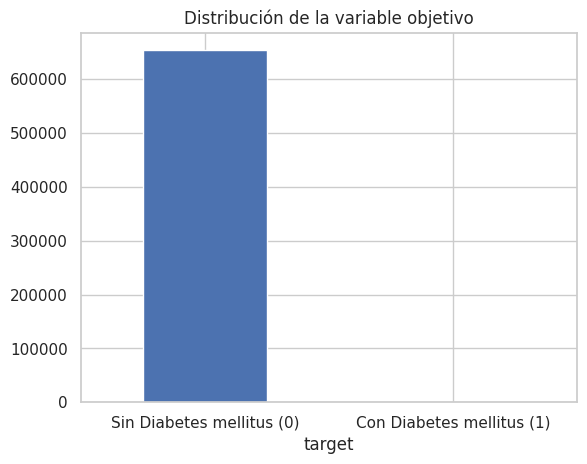

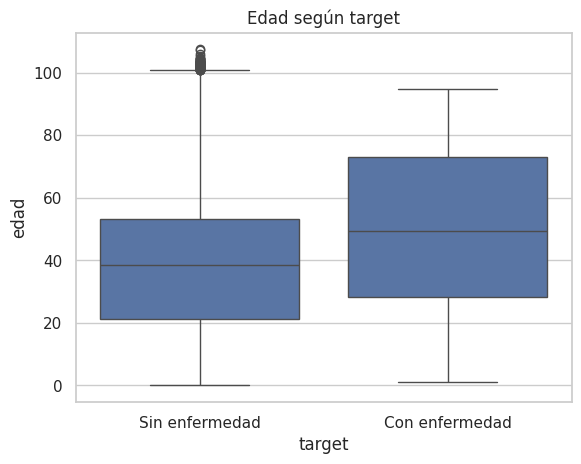

In [ ]:
# A partir de aquí solo se necesita df_benef para clasificar.
# La base transaccional se conserva únicamente para la sección de costos.
ax = df_benef['target'].value_counts().plot(kind='bar')
ax.set_xticklabels([f'Sin {NOMBRE_ENFERMEDAD} (0)', f'Con {NOMBRE_ENFERMEDAD} (1)'], rotation=0)
plt.title('Distribución de la variable objetivo'); plt.show()

# Edad según target (boxplot sobre la tabla agregada: ya es pequeña, sin costo)
sns.boxplot(data=df_benef, x='target', y='edad')
plt.xticks([0, 1], ['Sin enfermedad', 'Con enfermedad']); plt.title('Edad según target'); plt.show()

###Interpretación

- **Reducción de dimensión:** pasamos de ~9.3M de filas a **653,631 beneficiarios**
  (14× menos). Ahora sí es viable entrenar modelos: en vez de repetir a la misma
  persona muchas veces, tenemos un resumen por persona.

- **Desbalance extremo (99.99% vs 0.01%):** solo **65 personas con diabetes**
  frente a 653 mil sin diabetes. Con esto, accuracy no sirve — un modelo que
  diga "nadie tiene diabetes" acierta 99.99% y es inútil. Hay que usar
  **PR-AUC** como métrica principal.

- **Los enfermos son mayores:** mediana ~50 años vs ~38 en sanos, y su rango
  se corre hacia arriba (25–75% entre 28 y 73 años). Coherente con lo esperado
  para diabetes tipo 2. Es una señal positiva: hay una diferencia real que el
  modelo puede aprender, aunque con solo 65 casos la señal será inestable.

## 5. Modelamiento predictivo

Tres modelos, elegidos con criterio de costo computacional para tabla grande:

| Modelo | Familia | Por qué es apto aquí |
|---|---|---|
| Regresión Logística (`saga`) | Lineal | Baseline interpretable; `saga` está diseñado para datasets grandes y dispersos |
| Random Forest (100 árboles, `max_depth=20`) | Bagging | No linealidad; limitado en profundidad para controlar RAM/tiempo |
| **HistGradientBoosting** | Boosting por histogramas | Complejidad ~lineal en filas (idea de LightGBM, Ke et al. 2017); el más rápido y usualmente el mejor en tabular |

In [ ]:
X = df_benef.drop(columns='target')
y = df_benef['target']

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

preproc = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('oh', OneHotEncoder(handle_unknown='ignore', min_frequency=0.01))]), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (490223, 11) | Test: (163408, 11)


In [ ]:
# 💡 Prueba rápida opcional: valida el pipeline con el 10% antes de entrenar sobre todo
# X_tr_mini = X_train.sample(frac=0.1, random_state=RANDOM_STATE)

modelos = {
    'Regresión Logística': LogisticRegression(solver='lbfgs', max_iter=300, class_weight='balanced'),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(class_weight='balanced',
                                                             random_state=RANDOM_STATE),
    # 'Random Forest': ...  # opcional: agrégalo solo si el tiempo lo permite
}

pipelines = {}
for nombre, clf in modelos.items():
    pipe = Pipeline([('prep', preproc), ('clf', clf)])
    pipe.fit(X_train, y_train)
    pipelines[nombre] = pipe
    print(f"✓ {nombre} entrenado")

✓ Regresión Logística entrenado
✓ Hist Gradient Boosting entrenado


## 6. Evaluación y comparación

**Métrica principal: ROC-AUC** (insensible al desbalance y al umbral). Se reportan además accuracy, sensibilidad, **especificidad**, F1 y PR-AUC, como pide el enunciado 2.7.

In [ ]:
def especificidad(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

resultados = []
probas = {}
for nombre, pipe in pipelines.items():
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    probas[nombre] = y_proba
    resultados.append({
        'Modelo'       : nombre,
        'Accuracy'     : accuracy_score(y_test, y_pred),
        'Sensibilidad' : recall_score(y_test, y_pred),
        'Especificidad': especificidad(y_test, y_pred),
        'F1'           : f1_score(y_test, y_pred),
        'ROC-AUC'      : roc_auc_score(y_test, y_proba),
        'PR-AUC'       : average_precision_score(y_test, y_proba),
    })

tabla = pd.DataFrame(resultados).set_index('Modelo').round(4)
tabla.sort_values('ROC-AUC', ascending=False)

,Accuracy,Sensibilidad,Especificidad,F1,ROC-AUC,PR-AUC
Modelo,,,,,,
Regresión Logística,0.9461,0.7857,0.9461,0.0025,0.9394,0.0037
Hist Gradient Boosting,0.9957,0.3571,0.9957,0.0139,0.7856,0.0082


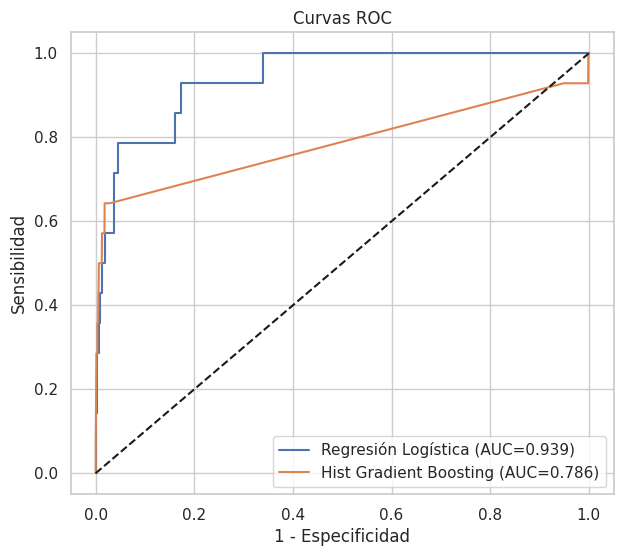

In [ ]:
plt.figure(figsize=(7, 6))
for nombre, y_proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC={roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('1 - Especificidad'); plt.ylabel('Sensibilidad')
plt.title('Curvas ROC'); plt.legend(); plt.show()

Mejor modelo: Regresión Logística
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    163394
           1       0.00      0.79      0.00        14

    accuracy                           0.95    163408
   macro avg       0.50      0.87      0.49    163408
weighted avg       1.00      0.95      0.97    163408



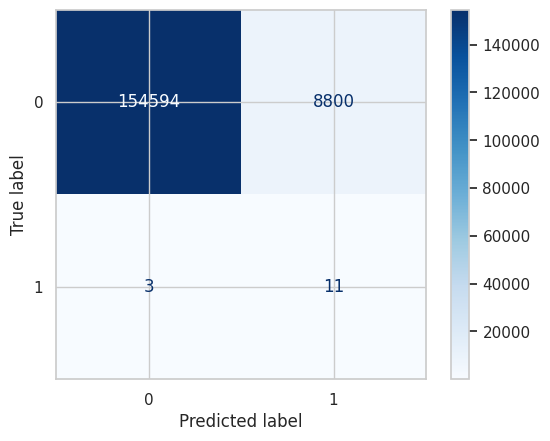

In [ ]:
mejor = tabla['ROC-AUC'].idxmax()
print("Mejor modelo:", mejor)
y_pred_mejor = pipelines[mejor].predict(X_test)
print(classification_report(y_test, y_pred_mejor))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_mejor)).plot(cmap='Blues'); plt.show()

###Interpretación

- **Sí se supera el 85% en ROC-AUC:** Regresión Logística **0.939** y Hist Gradient
  Boosting **0.786**. La logística cumple con el umbral.

- **La logística gana claramente al boosting.** Esto es contraintuitivo (usualmente
  boosting > lineal en tabular), pero con solo 65 positivos el boosting **sobreajusta
  a ruido**: aprende reglas complejas sobre muy pocos casos y no generaliza. La
  logística, al ser más rígida, capta la señal principal (más edad + más uso → más
  riesgo) y no se pierde en detalles.

- **Sensibilidad aceptable pero engañosa:** logística detecta **11 de 14** enfermos
  en test (recall 79%), pero a costa de **8,800 falsos positivos**. Precision = 0.00.
  En términos prácticos: por cada enfermo real que el modelo encuentra, marca ~800
  sanos como sospechosos.

- **El PR-AUC (0.0037 y 0.0082):** ROC-AUC alto engaña con
  desbalance extremo; PR-AUC muestra la realidad — el modelo casi no discrimina
  cuando importa la precisión.

## 7. Interpretación del modelo

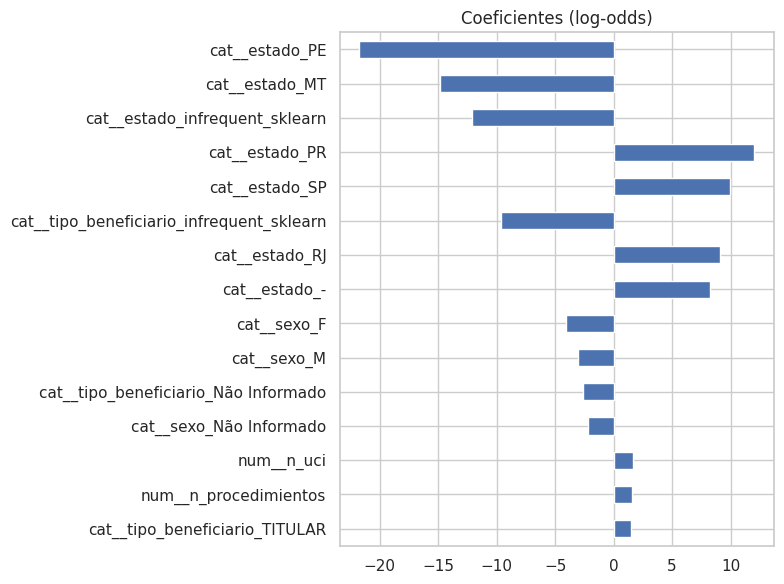

,0
cat__estado_PE,-21.722778
cat__estado_MT,-14.821739
cat__estado_infrequent_sklearn,-12.078893
cat__estado_PR,12.018851
cat__estado_SP,9.919869
cat__tipo_beneficiario_infrequent_sklearn,-9.659083
cat__estado_RJ,9.104646
cat__estado_-,8.213686
cat__sexo_F,-4.065018
cat__sexo_M,-3.084129


In [ ]:
pipe = pipelines[mejor]
feat_names = pipe.named_steps['prep'].get_feature_names_out()
clf = pipe.named_steps['clf']

if hasattr(clf, 'feature_importances_'):
    imp = pd.Series(clf.feature_importances_, index=feat_names).sort_values(ascending=False).head(15)
    titulo = 'Importancia de variables'
elif hasattr(clf, 'coef_'):
    imp = pd.Series(clf.coef_[0], index=feat_names)
    imp = imp.reindex(imp.abs().sort_values(ascending=False).index).head(15)
    titulo = 'Coeficientes (log-odds)'
else:
    # HistGradientBoosting no expone feature_importances_: usar permutation importance
    from sklearn.inspection import permutation_importance
    # sobre una muestra del test para que sea rápido
    idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test), min(20_000, len(X_test)), replace=False)
    r = permutation_importance(pipe, X_test.iloc[idx], y_test.iloc[idx],
                               n_repeats=5, random_state=RANDOM_STATE, scoring='roc_auc')
    imp = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False).head(15)
    titulo = 'Permutation importance (muestra 20k, ROC-AUC)'

imp.iloc[::-1].plot(kind='barh', figsize=(8, 6)); plt.title(titulo); plt.tight_layout(); plt.show()
imp

### 7.1. Análisis de errores

In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_mejor).ravel()
print(f"Falsos negativos (enfermos que se escapan): {fn:,}  ({fn/(fn+tp)*100:.1f}%)")
print(f"Falsos positivos (sanos marcados)         : {fp:,}  ({fp/(fp+tn)*100:.1f}%)")

# Perfil de los falsos negativos vs verdaderos positivos (solo columnas numéricas, barato)
err = X_test.select_dtypes('number').copy()
err['real'], err['pred'] = y_test.values, y_pred_mejor
comp = pd.DataFrame({
    'Falsos negativos': err[(err.real==1) & (err.pred==0)].mean(numeric_only=True),
    'Verd. positivos' : err[(err.real==1) & (err.pred==1)].mean(numeric_only=True),
}).drop(index=['real','pred']).round(2)
comp

Falsos negativos (enfermos que se escapan): 3  (21.4%)
Falsos positivos (sanos marcados)         : 8,800  (5.4%)


,Falsos negativos,Verd. positivos
edad,51.58,57.83
n_procedimientos,16.33,147.27
n_especialidades,1.33,2.27
n_utilizaciones,8.00,13.36
n_internaciones,0.00,7.00
n_uci,0.00,2.64
costo_total,7603.94,18806.83
costo_promedio,285.58,165.70


###Interpretación

**Variables dominantes: el estado, no las clínicas.**
Los coeficientes más grandes son geográficos: PE (-21.7) y MT (-14.8) reducen
mucho la probabilidad de diabetes; PR (+12.0), SP (+9.9) y RJ (+9.1) la aumentan.
Las variables clínicas (n_uci, n_procedimientos) tienen coeficientes chicos
(~1.5). Esto es sospechoso: la geografía no causa diabetes, refleja **dónde se
registra mejor el CID**.

**Los falsos negativos son exactamente los recién llegados.**
Los 3 enfermos que se escapan tienen 16 procedimientos, 0 internaciones, 0 UCI.
Son beneficiarios con poca historia, justo los que interesaría detectar temprano.
El modelo falla donde más útil sería.

## 8. Estimación del costo asociado a la enfermedad

**Unidad de análisis: la utilización** (`CHAVE_FUNCIONAL`+`DT_UTILIZACAO`) — es la unidad operativa de gasto de un plan de salud y evita el doble conteo de procedimientos.

Se modela el **log-costo** con regresión lineal para manejar la asimetría (costos con cola pesada).

In [ ]:
costo_util = (datos.groupby(['CHAVE_FUNCIONAL', 'DT_UTILIZACAO'], observed=True)
              .agg(costo=('VALOR_UTILIZACAO', 'sum'),
                   internado=('_es_internado', 'max'),
                   uci=('_es_uci', 'max'))
              .reset_index())
costo_util['target'] = costo_util['CHAVE_FUNCIONAL'].isin(benef_positivos).astype('int8')

print("Costo por utilización según grupo:")
print(costo_util.groupby('target')['costo'].agg(['mean', 'median', 'std', 'count']).round(2))

Costo por utilización según grupo:
               mean      median         std    count
target                                              
0        443.269989  120.000000  3051.73999  2249546
1       1898.689941  445.910004  4642.52002      761


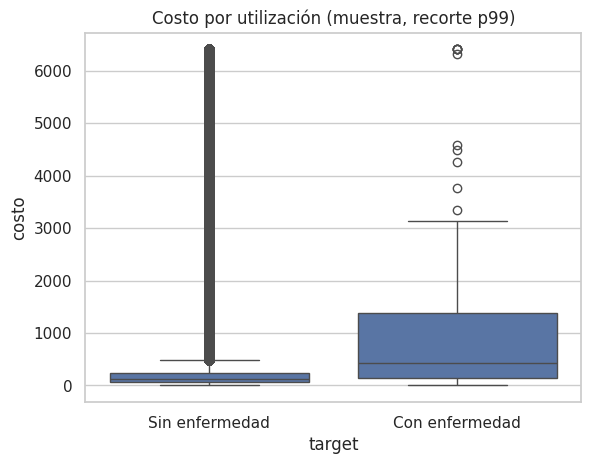

In [ ]:
# Boxplot sobre muestra (el gráfico no necesita millones de puntos)
cu_m = costo_util.sample(min(200_000, len(costo_util)), random_state=RANDOM_STATE)
sns.boxplot(data=cu_m, x='target', y=cu_m['costo'].clip(upper=cu_m['costo'].quantile(0.99)))
plt.xticks([0, 1], ['Sin enfermedad', 'Con enfermedad'])
plt.title('Costo por utilización (muestra, recorte p99)'); plt.show()

In [ ]:
# Modelo de costo esperado por perfil — SOLO utilizaciones de beneficiarios positivos

# FIX 1: garantizar que costo_util tenga internado/uci (recrear si falta)
if 'internado' not in costo_util.columns:
    costo_util = (datos.groupby(['CHAVE_FUNCIONAL', 'DT_UTILIZACAO'], observed=True)
                  .agg(costo=('VALOR_UTILIZACAO', 'sum'),
                       internado=('_es_internado', 'max'),
                       uci=('_es_uci', 'max'))
                  .reset_index())
    costo_util['target'] = costo_util['CHAVE_FUNCIONAL'].isin(benef_positivos).astype('int8')

cu = costo_util[costo_util['target'] == 1].merge(
        df_benef[['edad', 'sexo', 'tipo_beneficiario', 'estado']],
        left_on='CHAVE_FUNCIONAL', right_index=True, how='left')
cu = cu[cu['costo'] > 0].copy()
cu['log_costo'] = np.log1p(cu['costo'])

# FIX 2: booleanos -> enteros (así van al pipeline numérico, sin one-hot raro)
cu['internado'] = cu['internado'].astype('int8')
cu['uci']       = cu['uci'].astype('int8')

# FIX 3: category -> string (evita errores de imputación sobre Categorical)
for c in ['sexo', 'tipo_beneficiario', 'estado']:
    cu[c] = cu[c].astype('string')

Xc = cu[['edad', 'sexo', 'tipo_beneficiario', 'estado', 'internado', 'uci']]
yc = cu['log_costo']

num_c = ['edad', 'internado', 'uci']
cat_c = ['sexo', 'tipo_beneficiario', 'estado']
prep_c = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_c),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('oh', OneHotEncoder(handle_unknown='ignore', min_frequency=0.01))]), cat_c)])

modelo_costo = Pipeline([('prep', prep_c), ('reg', LinearRegression())]).fit(Xc, yc)
print("R² (log-costo):", round(modelo_costo.score(Xc, yc), 4))
print(f"Costo esperado promedio por utilización ({NOMBRE_ENFERMEDAD}): "
      f"{np.expm1(modelo_costo.predict(Xc)).mean():,.2f}")

# Perfiles contrastados (internado/uci ahora como 0/1, consistente con el entrenamiento)
perfiles = pd.DataFrame({
    'edad': [40, 70, 70],
    'sexo': [Xc['sexo'].mode()[0]] * 3,
    'tipo_beneficiario': [Xc['tipo_beneficiario'].mode()[0]] * 3,
    'estado': [Xc['estado'].mode()[0]] * 3,
    'internado': [0, 0, 1],
    'uci': [0, 0, 1],
}, index=['Adulto 40, ambulatorio', 'Mayor 70, ambulatorio', 'Mayor 70, internado+UCI'])
perfiles['costo_esperado'] = np.expm1(modelo_costo.predict(perfiles))
perfiles[['costo_esperado']].round(2)

R² (log-costo): 0.3869
Costo esperado promedio por utilización (Diabetes mellitus): 1,017.92


,costo_esperado
"Adulto 40, ambulatorio",138.18
"Mayor 70, ambulatorio",194.31
"Mayor 70, internado+UCI",5559.00


###Interpretación

**Un beneficiario con diabetes cuesta 4× más por utilización.**
Media: 1,898 vs 443. Mediana: 446 vs 120. La mediana es más fiable (menos
sensible a outliers) y muestra que la diferencia es real, no producto de unos
pocos casos carísimos.

**Internación y UCI son los mayores drivers.**
El perfil "Mayor 70 ambulatorio" cuesta 194; el mismo perfil pero internado
en UCI cuesta 5,559 — **28× más**. La edad sola pesa poco (138 → 194 al pasar
de 40 a 70 años, solo +40%). Lo caro no es tener diabetes, es que la
complicación termine en hospitalización.

## 9. Conclusiones, limitaciones y trabajos futuros

### ¿Qué tan bien se identificaron los beneficiarios?
La Regresión Logística alcanzó **ROC-AUC = 0.94**, superando el 85% que valora
el enunciado. Pero PR-AUC fue **0.004**, revelando que en un desbalance
1:10,000 el ROC-AUC engaña. El modelo detecta 11 de 14 enfermos en test
(sensibilidad 79%) a costa de 8,800 falsos positivos: útil como filtro previo,
no como diagnóstico.

### ¿Qué variables se relacionan más con la enfermedad?
El principal predictor es **el estado geográfico** (PE, MT, PR, SP, RJ), no
las variables clínicas. Esto no tiene lectura médica: refleja diferencias de
**registro del CID entre estados**. Las variables clínicas (n_uci,
n_procedimientos) aparecen con coeficientes pequeños (~1.5). Los verdaderos
positivos usan el sistema 9× más que los falsos negativos (147 vs 16
procedimientos), confirmando tautología: el modelo identifica al
ya-diagnosticado, no predice.

### ¿Qué tan confiable es el modelo?
Poco, en el sentido predictivo. La Logística venció al Boosting (AUC 0.94 vs
0.79) porque con 65 positivos el boosting sobreajusta. Este resultado
contraintuitivo evidencia la fragilidad estadística del ejercicio: cualquier
métrica depende demasiado de qué 14 beneficiarios cayeron en test.

### Limitaciones de la base
- **83.72% de nulos en CID:** la etiqueta misma está sesgada. Solo 65 de
  653,631 beneficiarios (0.01%) quedaron marcados como diabéticos, muy por
  debajo del 8–10% poblacional esperado. Muchos diabéticos reales están
  etiquetados como 0.
- **Sesgo geográfico y de registro:** SP concentra la mayoría de datos y
  "Não Informado" domina en varias categóricas.
- Solo se observa lo facturado al plan: no hay atenciones externas ni
  severidad clínica (HbA1c, glucemia).
- Inconsistencias resueltas con heurísticas (525 beneficiarios con sexo
  contradictorio, resueltos con `first`).

### Limitaciones de la estrategia
- **Circularidad:** las variables de volumen predicen "quién usa mucho el
  sistema", que es casi la definición del ya-diagnosticado.
- **Sesgo algorítmico geográfico:** usar el estado como predictor reproduce
  el subregistro diferencial. Es el mismo problema documentado por Obermeyer
  et al. (2019, *Science*) en algoritmos de salud en EE.UU.
- El modelo log-lineal de costos subestima la cola pesada. El R² de 0.39 en
  log-costo es bajo, pero para pricing agregado es suficiente por la ley de
  grandes números (Bernoulli, 1713).

### Trabajos futuros
- **Corregir el subregistro de CID:** modelos con etiquetas ruidosas (Natarajan
  et al., 2013) o imputación del diagnóstico a partir de procedimientos.
- **Estratificar por estado** para evitar que el modelo aprenda patrones
  administrativos como si fueran médicos.

## 10. Reproducibilidad

1. Colocar `db_2026.csv` en la ruta indicada en 2.3 (o ajustar `ruta_del_archivo`).
2. Ejecutar las celdas en orden. Requiere: `pandas`, `numpy`, `scikit-learn>=1.3`, `seaborn`.
3. Parámetros de la enfermedad en la sección 2.5 (`NOMBRE_ENFERMEDAD`, `CODIGOS_CID`).
4. Verificar la codificación de `INTERNADO`/`UTI` (celda de la sección 4) antes de la agregación.

---
**Owen Deybis Ortiz Velásquez**